BUSINESS OVERVIEW
Total Sales      : 233,650,194.43
Total Orders     : 201,716
Average Discount : 6.07%


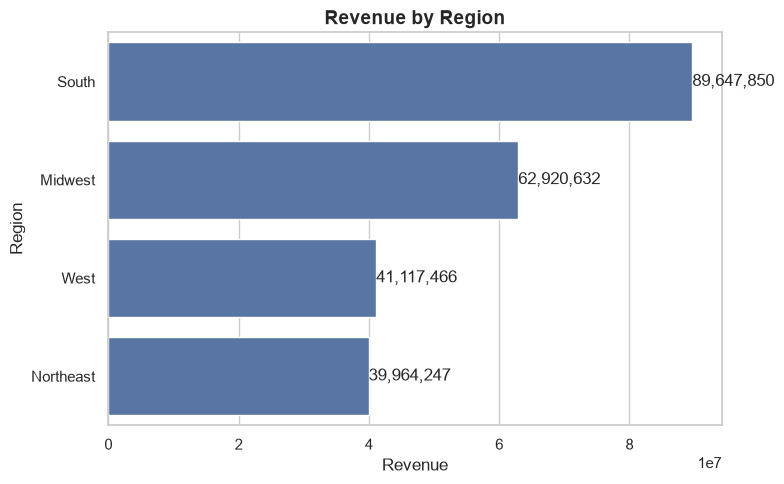

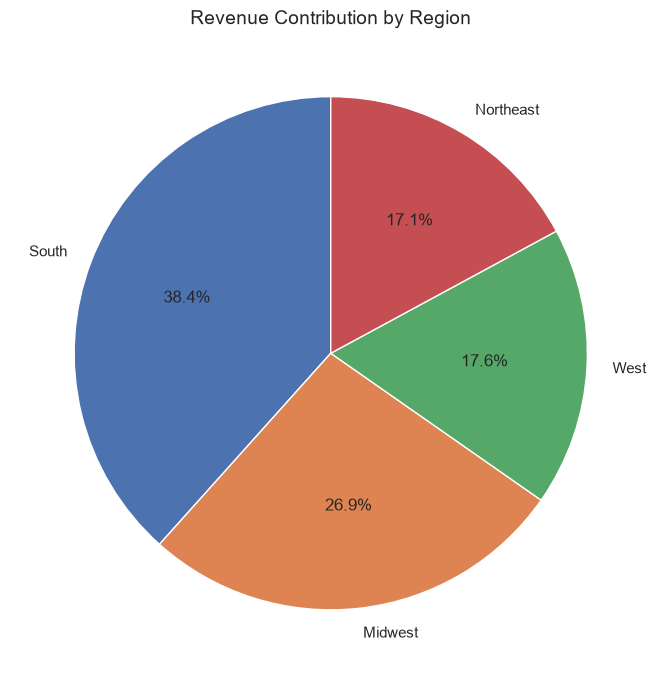

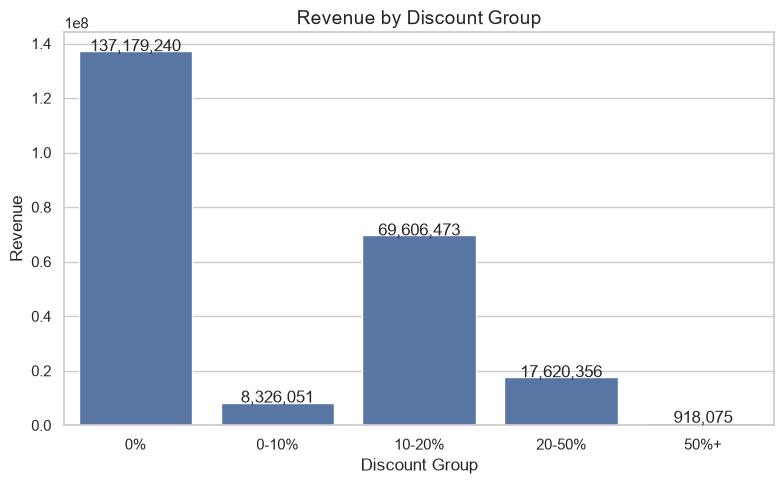

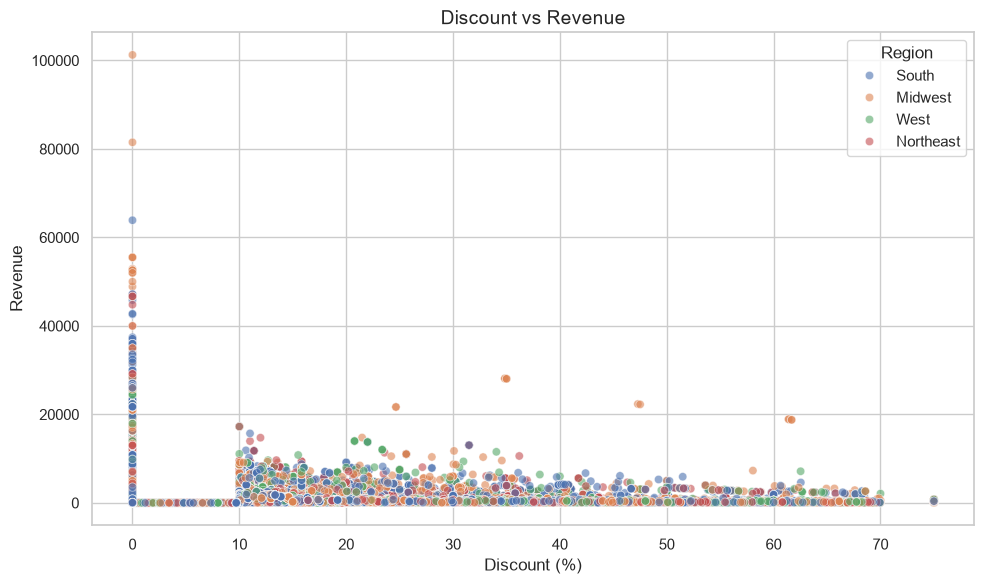

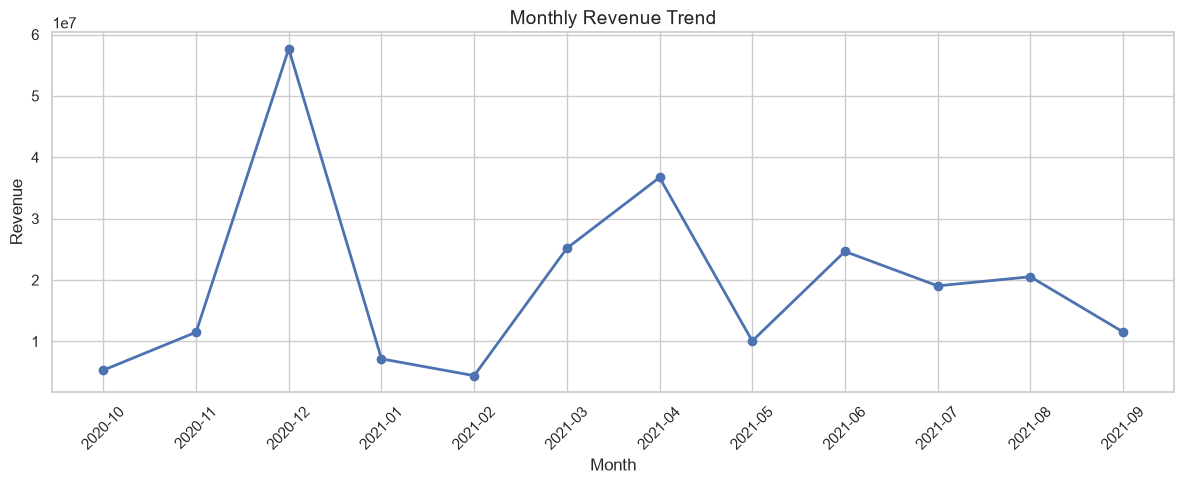

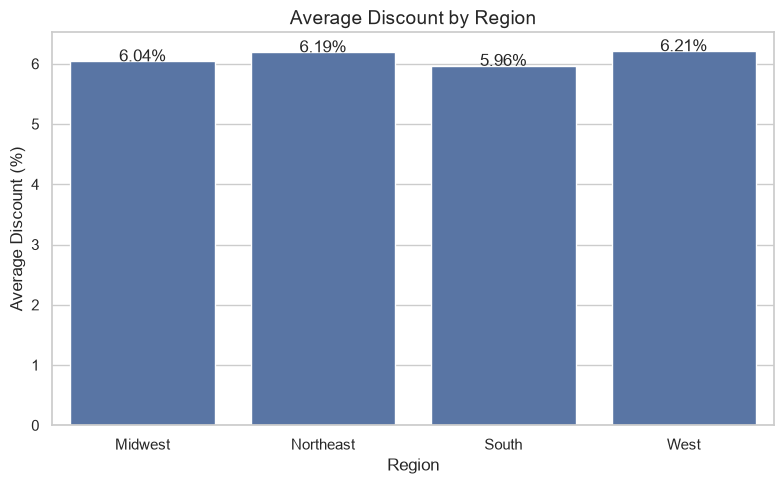

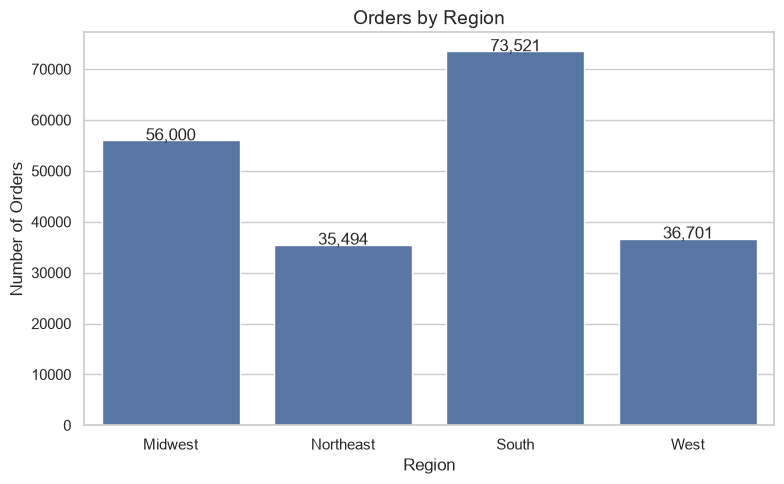


KEY INSIGHTS
1. South is the highest revenue-generating region.
2. South contributes the largest share of total revenue.
3. Most revenue comes from orders with no or low discounts.
4. Discounts above 20% generate relatively low revenue.
5. There is no clear positive relationship between higher discounts and higher revenue.
6. South should remain the company's priority market for future growth.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 1. ĐỌC DỮ LIỆU
# =====================================================

df = pd.read_csv("data/raw/sales_06_FY2020-21.csv", low_memory=False)

# Chuyển kiểu dữ liệu ngày
df["order_date"] = pd.to_datetime(df["order_date"])

# Thiết lập giao diện
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# =====================================================
# CHAPTER 1 - BUSINESS OVERVIEW
# =====================================================

print("=" * 60)
print("BUSINESS OVERVIEW")
print("=" * 60)

total_sales = df["total"].sum()
total_orders = df["order_id"].nunique()
avg_discount = df["Discount_Percent"].mean()

print(f"Total Sales      : {total_sales:,.2f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Average Discount : {avg_discount:.2f}%")

# =====================================================
# CHAPTER 2 - SALES BY REGION
# =====================================================

sales_region = (
    df.groupby("Region")["total"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=sales_region.values,
    y=sales_region.index
)

plt.title("Revenue by Region", fontsize=14, fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Region")

for i, v in enumerate(sales_region.values):
    ax.text(v, i, f"{v:,.0f}", va="center")

plt.tight_layout()
plt.show()

# =====================================================
# CHAPTER 3 - REGION CONTRIBUTION
# =====================================================

plt.figure(figsize=(7,7))

plt.pie(
    sales_region.values,
    labels=sales_region.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Contribution by Region", fontsize=14)

plt.tight_layout()
plt.show()

# =====================================================
# CHAPTER 4 - DISCOUNT GROUP
# =====================================================

def discount_group(x):

    if x == 0:
        return "0%"
    elif x <= 10:
        return "0-10%"
    elif x <= 20:
        return "10-20%"
    elif x <= 50:
        return "20-50%"
    else:
        return "50%+"

df["Discount Group"] = df["Discount_Percent"].apply(discount_group)

sales_discount = (
    df.groupby("Discount Group")["total"]
      .sum()
      .reindex(["0%", "0-10%", "10-20%", "20-50%", "50%+"])
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=sales_discount.index,
    y=sales_discount.values
)

plt.title("Revenue by Discount Group", fontsize=14)

plt.xlabel("Discount Group")
plt.ylabel("Revenue")

for i, v in enumerate(sales_discount.values):
    ax.text(i, v, f"{v:,.0f}", ha="center")

plt.tight_layout()
plt.show()

# =====================================================
# CHAPTER 5 - DISCOUNT VS SALES
# =====================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Discount_Percent",
    y="total",
    hue="Region",
    alpha=0.6
)

plt.title("Discount vs Revenue", fontsize=14)
plt.xlabel("Discount (%)")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

# =====================================================
# CHAPTER 6 - MONTHLY SALES TREND
# =====================================================

monthly_sales = (
    df.groupby(df["order_date"].dt.to_period("M"))["total"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend", fontsize=14)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

# =====================================================
# CHAPTER 7 - AVERAGE DISCOUNT BY REGION
# =====================================================

avg_discount_region = (
    df.groupby("Region")["Discount_Percent"]
      .mean()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=avg_discount_region.index,
    y=avg_discount_region.values
)

plt.title("Average Discount by Region", fontsize=14)

plt.xlabel("Region")
plt.ylabel("Average Discount (%)")

for i, v in enumerate(avg_discount_region.values):
    ax.text(i, v, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.show()

# =====================================================
# CHAPTER 8 - ORDERS BY REGION
# =====================================================

orders_region = (
    df.groupby("Region")["order_id"]
      .nunique()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=orders_region.index,
    y=orders_region.values
)

plt.title("Orders by Region", fontsize=14)

plt.xlabel("Region")
plt.ylabel("Number of Orders")

for i, v in enumerate(orders_region.values):
    ax.text(i, v, f"{v:,}", ha="center")

plt.tight_layout()
plt.show()

# =====================================================
# CHAPTER 9 - KEY INSIGHTS
# =====================================================

print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

print("1. South is the highest revenue-generating region.")
print("2. South contributes the largest share of total revenue.")
print("3. Most revenue comes from orders with no or low discounts.")
print("4. Discounts above 20% generate relatively low revenue.")
print("5. There is no clear positive relationship between higher discounts and higher revenue.")
print("6. South should remain the company's priority market for future growth.")
